# Customer Churn Prediction Model

Customer churn is an important business problem for subscription-based platforms such as Netflix. Identifying customers who are likely to stop using a service can help businesses understand user behavior and develop targeted retention strategies.

In this notebook, we build a **machine learning-based customer churn prediction system** using customer demographics, account information, and engagement behavior. The objective is to predict whether a customer is likely to churn based on their historical activity and usage patterns.

The modeling workflow includes:

* Preparing the dataset for training the model
* Separating features and the target variable
* Splitting the data into training and testing sets
* Building a preprocessing pipeline for numerical and categorical features
* Training and comparing **Random Forest** and **XGBoost** classifiers
* Evaluating model performance using multiple classification metrics
* Selecting and saving the best-performing model for future predictions

The final trained model will later be integrated into a **Streamlit application**, where users can enter customer information and receive a predicted churn probability.

This notebook focuses specifically on the **churn prediction modeling pipeline**. Customer segmentation will be developed separately as an unsupervised learning component of the overall project.


Importing Libraries 

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier

import joblib

In [16]:
df = pd.read_csv("E:\\Netflix Customer Segmentation & Retention Analysis\\Data\\netflix_user_behavior_churn_50000v2.csv")

In [17]:
df.head()

,user_id,age,gender,region,subscription_type,payment_method,primary_device,account_age_months,favorite_genre,time_of_day,recommendation_source,session_count,avg_watch_time_minutes_per_week,watch_sessions_per_week,completion_rate,avg_rating_given,app_rating,recommendation_click_rate,days_since_last_login,churned
0,N00001,33,Male,Europe,Basic,Credit Card,Smart TV,38,Comedy,Afternoon,Trending,1,259,4,79,4,4,48,3,0
1,N00002,41,Male,Africa,Premium,Credit Card,Tablet,49,Comedy,Evening,Search,1,164,4,69,4,4,32,30,0
2,N00003,28,Female,Europe,Standard,Gift Card,Laptop,20,Drama,Evening,Ads,1,304,5,75,4,3,31,5,1
3,N00004,40,Female,North America,Basic,Credit Card,Mobile,19,Action,Evening,Algorithm,1,145,6,79,4,4,39,38,0
4,N00005,54,Male,Europe,Standard,Paypal,Mobile,51,Romance,Evening,Friend,3,108,1,58,5,4,50,5,0


## Target Feature -> Churned

In [18]:
X = df.drop(columns=['user_id', 'churned'])
y = df['churned']

In [19]:
X.shape

(50000, 18)

In [20]:
y.shape

(50000,)

## Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Numerical and Categorical Features

In [22]:
numerical_features = [
    'age',
    'account_age_months',
    'session_count',
    'avg_watch_time_minutes_per_week',
    'watch_sessions_per_week',
    'completion_rate',
    'avg_rating_given',
    'app_rating',
    'recommendation_click_rate',
    'days_since_last_login'
]

categorical_features = [
    'gender',
    'region',
    'subscription_type',
    'payment_method',
    'primary_device',
    'favorite_genre',
    'time_of_day',
    'recommendation_source'
]

In [23]:
preprocessor = ColumnTransformer(transformers=[
    (
    'num', StandardScaler(), 
     numerical_features
),
(
    'cat',
    OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features

        )
    ]
)

## Logistic Regression Baseline

In [24]:
lr_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=20
        ))
    ]
)

Train the baseline model

In [25]:
lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['age','gender','region',...,'app_rating','recommendation_click_rate', 'days_since_last_login']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

In [26]:
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1] # Get the predicted probability of churn (class 1) for the test set

### Evaluation Function

In [27]:
def evaluate_model(model_name, y_test, y_pred, y_prob):

    #metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)\


    print(f"\n{'='*50}")
    print(model_name)
    print(f"{'='*50}")
    
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }
    

Evaluate Logistic Regression:

In [28]:
lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_prob_lr
)


Logistic Regression
Accuracy : 0.8767
Precision: 0.7628
Recall   : 0.5963
F1 Score : 0.6693
ROC-AUC  : 0.9067
PR-AUC   : 0.7636

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7907
           1       0.76      0.60      0.67      2093

    accuracy                           0.88     10000
   macro avg       0.83      0.77      0.80     10000
weighted avg       0.87      0.88      0.87     10000



## Train Random Forest Model

In [29]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [30]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['age','gender','region',...,'app_rating','recommendation_click_rate', 'days_since_last_login']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

In [31]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1 ] # Get the predicted probability of churn (class 1) for the test set

### Evaluate RandomForestClassifier Model 

In [32]:
rf_results = evaluate_model('Random Forest Classsifier',
                 y_test,
                 y_pred_rf, 
                 y_prob_rf
                )


Random Forest Classsifier
Accuracy : 0.8714
Precision: 0.7781
Recall   : 0.5394
F1 Score : 0.6371
ROC-AUC  : 0.8968
PR-AUC   : 0.7428

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      7907
           1       0.78      0.54      0.64      2093

    accuracy                           0.87     10000
   macro avg       0.83      0.75      0.78     10000
weighted avg       0.86      0.87      0.86     10000



### Train XGBoost Model

In [33]:
xgb_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric='logloss'
        ))
    ]
)

In [34]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['age','gender','region',...,'app_rating','recommendation_click_rate', 'days_since_last_login']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

In [35]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [36]:
xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)


XGBoost
Accuracy : 0.8748
Precision: 0.7504
Recall   : 0.6020
F1 Score : 0.6681
ROC-AUC  : 0.9028
PR-AUC   : 0.7593

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7907
           1       0.75      0.60      0.67      2093

    accuracy                           0.87     10000
   macro avg       0.83      0.77      0.80     10000
weighted avg       0.87      0.87      0.87     10000



In [37]:
print(classification_report(y_test, y_pred_xgb, labels=[0,1]))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7907
           1       0.75      0.60      0.67      2093

    accuracy                           0.87     10000
   macro avg       0.83      0.77      0.80     10000
weighted avg       0.87      0.87      0.87     10000



In [38]:
results = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results
])

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.8767,0.762836,0.596273,0.669348,0.906678,0.763597
1,Random Forest Classsifier,0.8714,0.778084,0.539417,0.637133,0.896797,0.742838
2,XGBoost,0.8748,0.750447,0.602007,0.668081,0.902832,0.759254


## Confusion Matrix

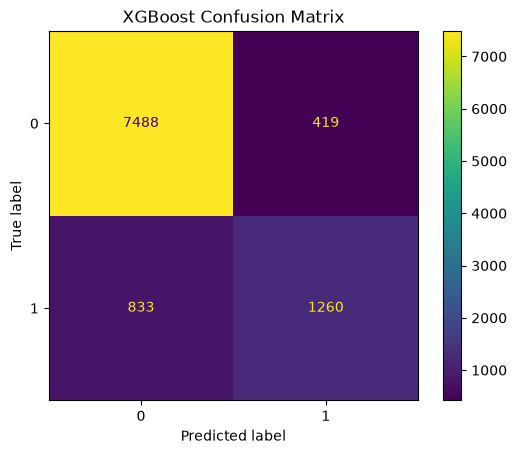

In [39]:
cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

## AUC-ROC Curve

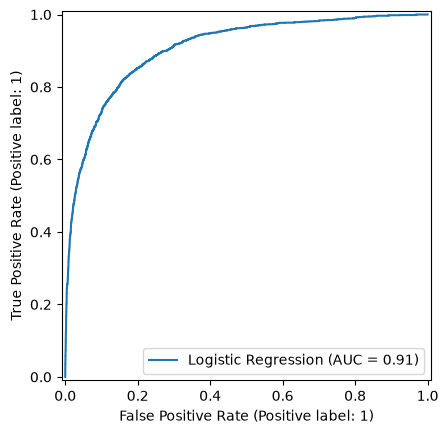

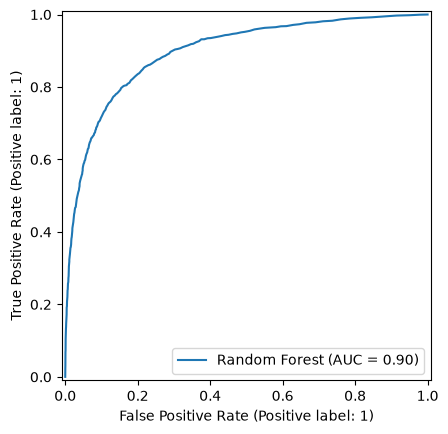

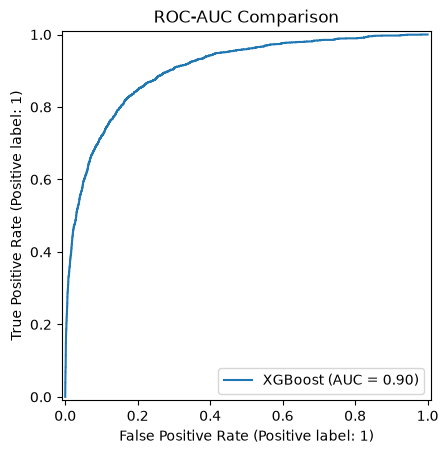

In [40]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("ROC-AUC Comparison")
plt.show()

## Precision Recall Curve

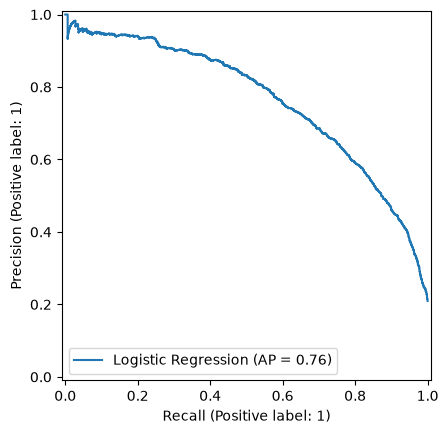

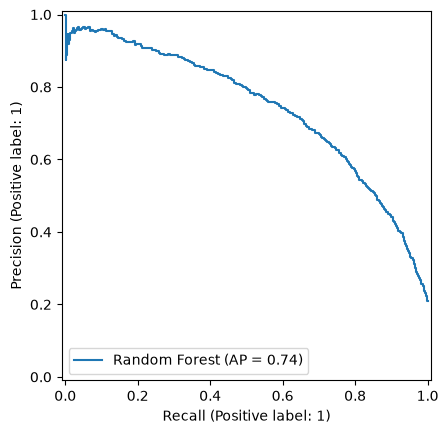

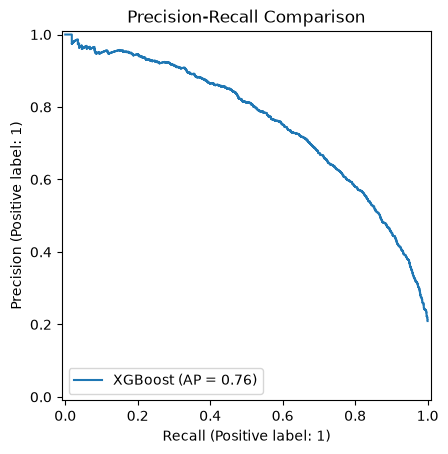

In [41]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("Precision-Recall Comparison")
plt.show()

## Hyperparameter Tunning
Tunning models with different parameters

## Random Forest Tune

In [42]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [43]:
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [44]:
rf_params = {
    'model__n_estimators': [300, 500, 700, 1000],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

In [45]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [46]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=30,
    scoring='accuracy',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosin

In [47]:
print("Best Random Forest Parameters:")
print(rf_search.best_params_)

Best Random Forest Parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}


In [48]:
print("Best Accuracy:")
print(rf_search.best_score_)

Best Accuracy:
0.87005


In [49]:
best_rf = rf_search.best_estimator_

## XGBoost Tune

In [50]:
xgb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1
        ))
    ]
)

In [51]:
xgb_params = {
    'model__n_estimators': [200, 300, 500, 700],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [3, 4, 5, 6, 8],
    'model__min_child_weight': [1, 3, 5],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__gamma': [0, 0.1, 0.3, 0.5]
}

In [52]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=30,
    scoring='accuracy',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a be

In [53]:
xgb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1
        ))
    ]
)

In [54]:
print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

Best XGBoost Parameters:
{'model__subsample': 0.7, 'model__n_estimators': 300, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__gamma': 0.5, 'model__colsample_bytree': 0.9}


In [55]:
print("Best CV ROC-AUC:")
print(xgb_search.best_score_)

Best CV ROC-AUC:
0.8749999999999998


In [56]:
best_xgb = xgb_search.best_estimator_

In [57]:
best_rf_pred = best_rf.predict(X_test)
best_rf_prob = best_rf.predict_proba(X_test)[:, 1]

best_xgb_pred = best_xgb.predict(X_test)
best_xgb_prob = best_xgb.predict_proba(X_test)[:, 1]

In [58]:
rf_final_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    best_rf_pred,
    best_rf_prob
)

xgb_final_results = evaluate_model(
    "Tuned XGBoost",
    y_test,
    best_xgb_pred,
    best_xgb_prob
)


Tuned Random Forest
Accuracy : 0.8702
Precision: 0.7747
Recall   : 0.5356
F1 Score : 0.6333
ROC-AUC  : 0.8977
PR-AUC   : 0.7440

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      7907
           1       0.77      0.54      0.63      2093

    accuracy                           0.87     10000
   macro avg       0.83      0.75      0.78     10000
weighted avg       0.86      0.87      0.86     10000


Tuned XGBoost
Accuracy : 0.8771
Precision: 0.7590
Recall   : 0.6049
F1 Score : 0.6732
ROC-AUC  : 0.9045
PR-AUC   : 0.7605

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7907
           1       0.76      0.60      0.67      2093

    accuracy                           0.88     10000
   macro avg       0.83      0.78      0.80     10000
weighted avg       0.87      0.88      0.87     10000



## Comparing Both Model After Tunning

In [59]:
final_results = pd.DataFrame([
    rf_final_results,
    xgb_final_results
])

final_results.sort_values(
    by='ROC-AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
1,Tuned XGBoost,0.8771,0.758993,0.604873,0.673225,0.904491,0.760525
0,Tuned Random Forest,0.8702,0.774706,0.535595,0.633333,0.897653,0.744043


Final Model Selection

In [60]:
if rf_final_results['ROC-AUC'] >= xgb_final_results['ROC-AUC']:
    final_model = best_rf
    final_model_name = "Tuned_Random_Forest"
else:
    final_model = best_xgb
    final_model_name = "Tuned_XGBoost"

print("Final Model:", final_model_name)

Final Model: Tuned_XGBoost


## Save final model

In [ ]:
final_model = 'XG'

In [62]:
import pickle

In [63]:
filename = 'XGBoost_model.pkl'

In [64]:
pickle.dump(xgb_search, open(filename, 'wb'))

In [65]:

load_model = pickle.load(open(filename, 'rb'))

In [66]:

model_score_r1 = load_model.score(X_test, y_test)

In [67]:

model_score_r1

0.8771